# Series de Tiempo II

In [45]:
import warnings 
warnings.filterwarnings('ignore')

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

In [47]:
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
import statsmodels.api as sm
from numpy.random import normal, seed
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima_model import ARIMA

In [48]:
df_apple = pd.read_csv('./AAPL.csv',index_col='Date',parse_dates=['Date'])
df_tesla = pd.read_csv('./TSLA.csv',index_col='Date',parse_dates=['Date'])

In [49]:
df_apple.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,43.181805,43.613062,42.877969,42.897572,108174400,0.0,0.0
2019-06-03,43.027439,43.595909,41.721424,42.463867,161584400,0.0,0.0
2019-06-04,42.988224,44.063910,42.762796,44.017353,123872000,0.0,0.0
2019-06-05,45.154295,45.328268,44.384898,44.727940,119093600,0.0,0.0
2019-06-06,44.860258,45.445882,44.632378,45.384624,90105200,0.0,0.0
2019-06-07,45.700720,47.026338,45.519399,46.592632,122737600,0.0,0.0
2019-06-10,46.999386,47.871695,46.952829,47.188061,104883600,0.0,0.0
2019-06-11,47.746726,48.026062,47.437989,47.734474,107731600,0.0,0.0
2019-06-12,47.523745,48.018709,47.386528,47.582554,73012800,0.0,0.0


In [50]:
df_tesla.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,37.020000,37.984001,36.820000,37.032001,52033500,0,0.0
2019-06-03,37.102001,37.335999,35.397999,35.793999,65322000,0,0.0
2019-06-04,36.220001,38.796001,35.922001,38.720001,69037500,0,0.0
2019-06-05,39.736000,40.256001,38.369999,39.318001,67554000,0,0.0
2019-06-06,40.888000,42.200001,40.360001,41.189999,101211000,0,0.0
2019-06-07,41.000000,42.167999,40.700001,40.900002,80017500,0,0.0
2019-06-10,42.049999,43.388000,41.801998,42.576000,52925000,0,0.0
2019-06-11,43.827999,44.180000,42.700001,43.419998,58267500,0,0.0
2019-06-12,44.590000,44.675999,41.799999,41.852001,75987500,0,0.0


### Autocorrelación

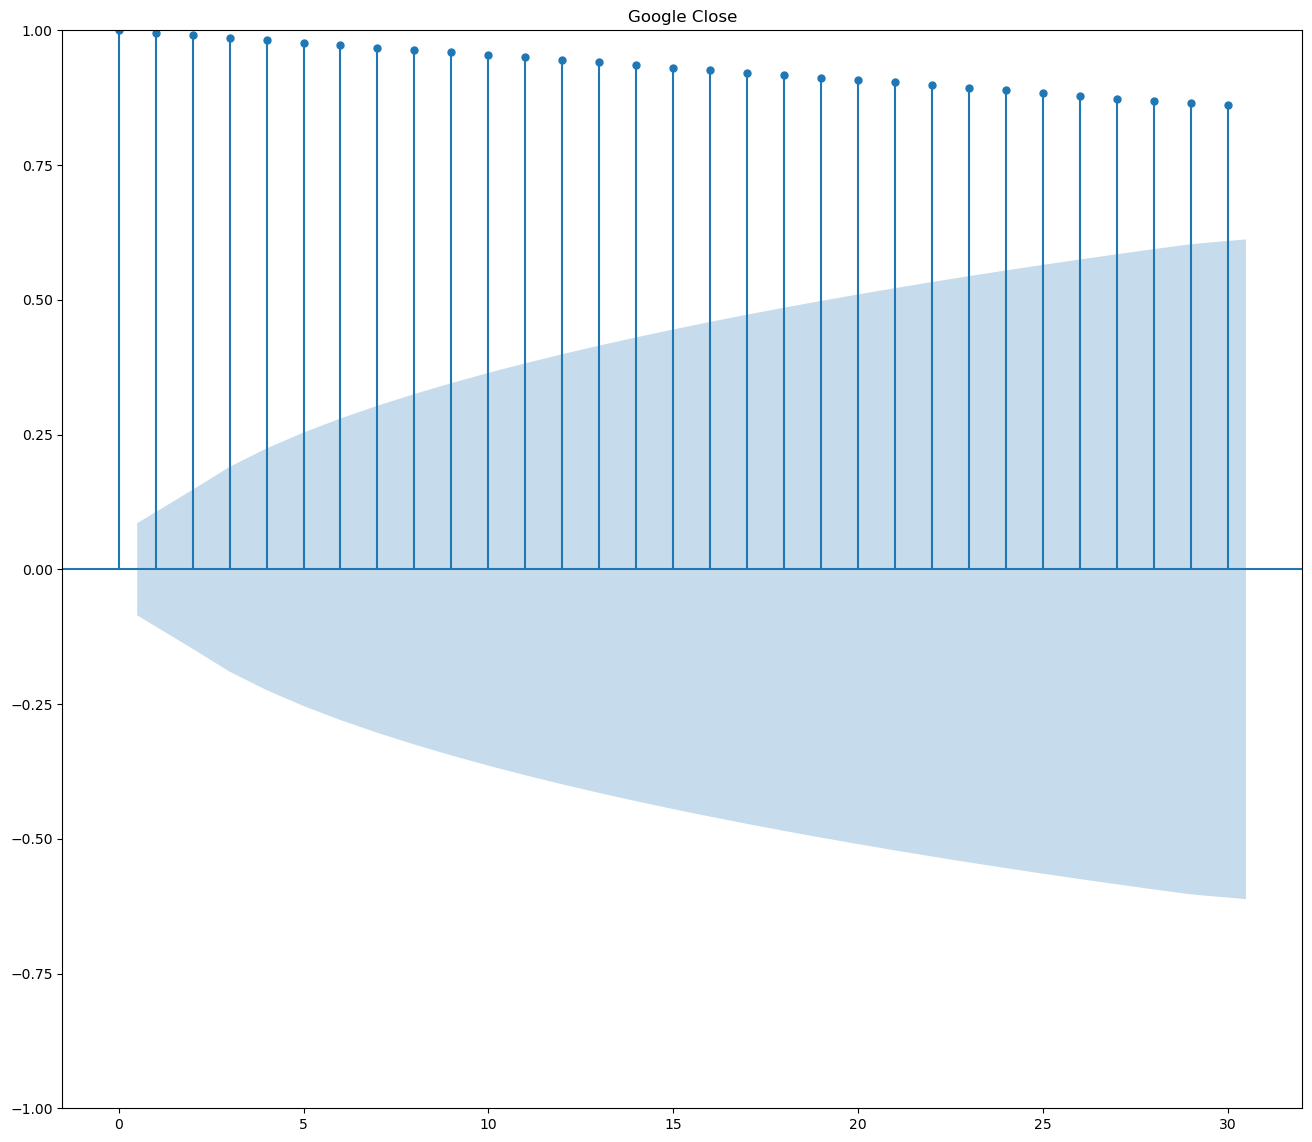

In [51]:
plot_acf(df_tesla['Close'],lags=30,title='Google Close')
plt.show()

### Función parcial de acutocorrelación

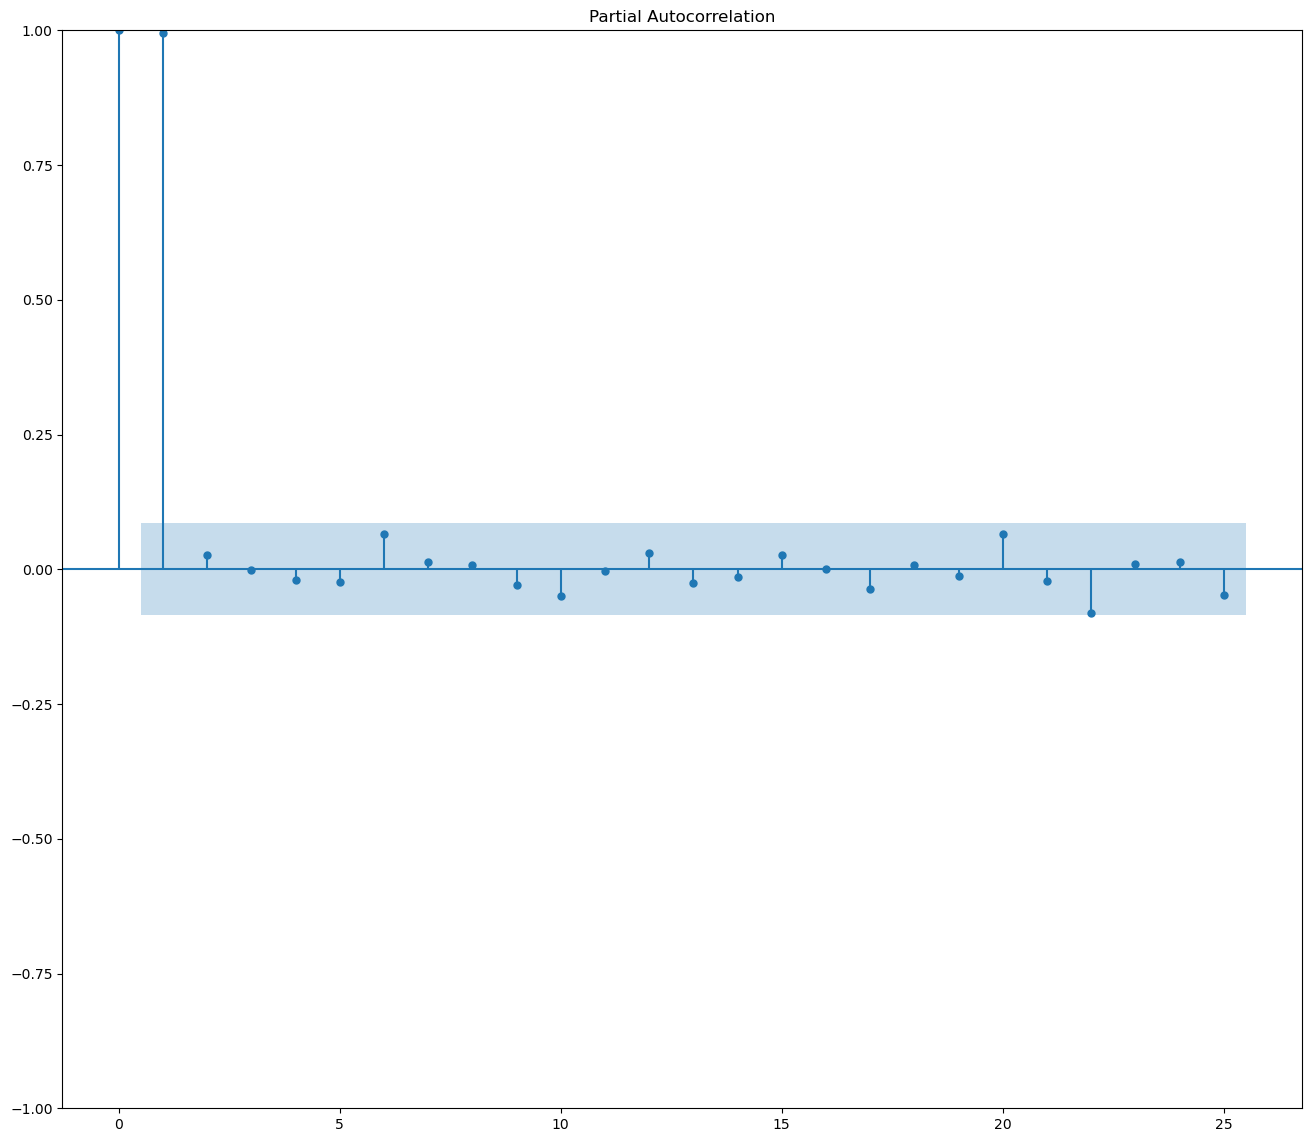

In [52]:
plot_pacf(df_tesla['Close'],lags=25)
plt.show()

### White Noise

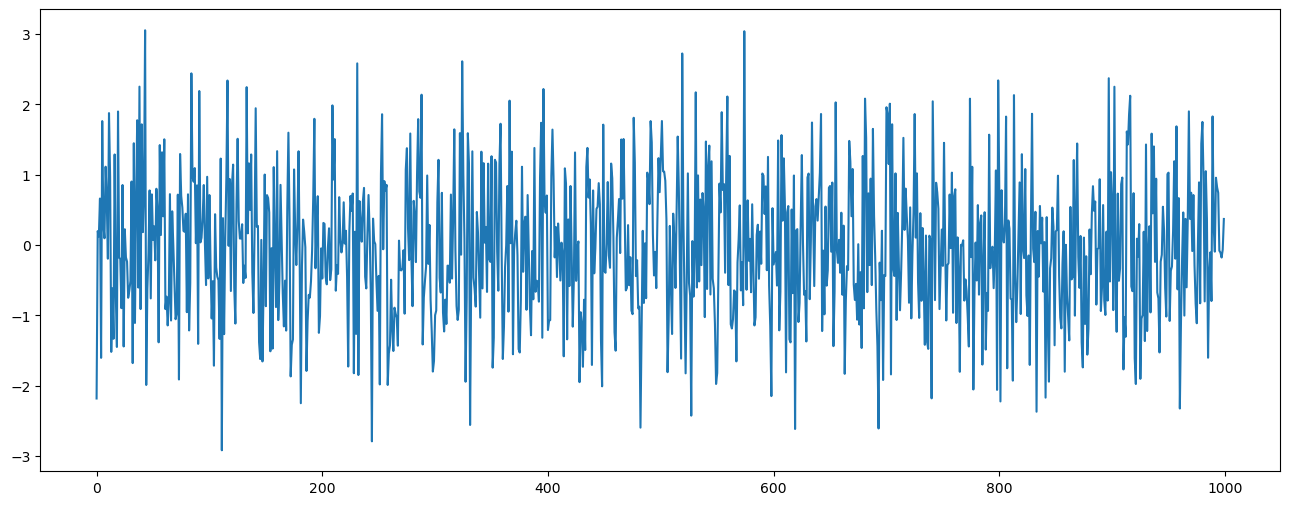

In [53]:
from pylab import rcParams
rcParams['figure.figsize'] = 16,6
white_noise = np.random.normal(loc=0,scale=1,size=1000)
plt.plot(white_noise)

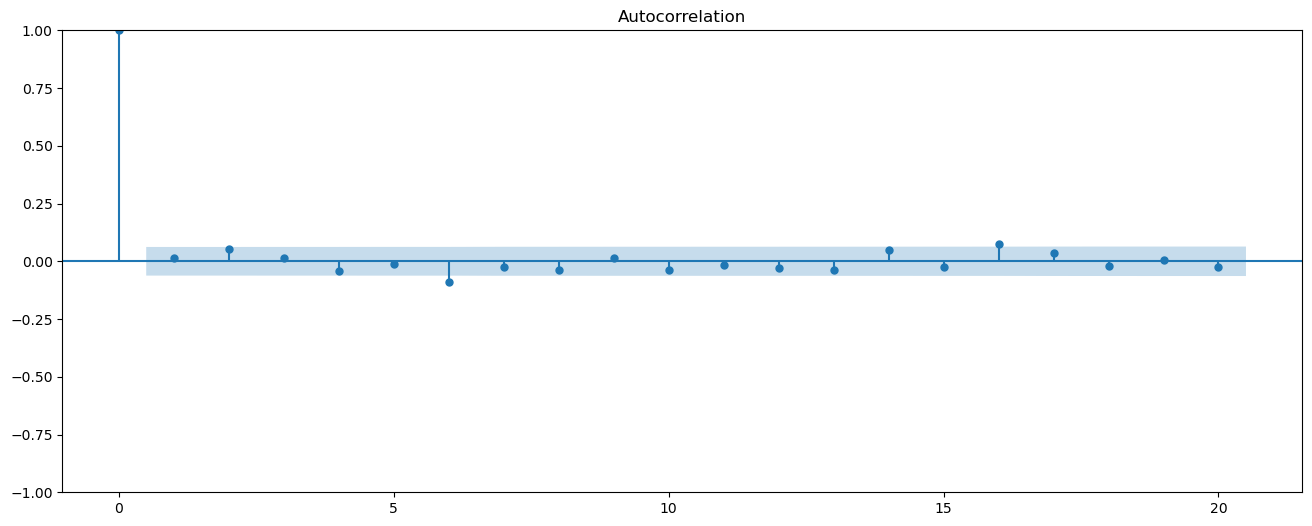

In [54]:
plot_acf(white_noise,lags=20)
plt.show()

In [55]:
from scipy.stats import norm
import pandas as pd

delta = 0.25
dt = 0.1

x = 0.0
xini = 0

n = 10

for k in range(n):
    x = x + norm.rvs(scale=delta**2*dt)
    print(x)

-0.006677930105012083
-0.010158743842783305
-0.015826999200356975
-0.00800905665062352
-0.004499010078161239
-5.610345963550766e-05
-0.002713188397887415
-0.00653321567096224
-0.011712817030944357
-0.013107488934206614


In [56]:
ntra = 10
n = 20

res = []
dfres = pd.DataFrame().assign(traj=0,nsample=0,sample=0)

In [57]:
dfres

,traj,nsample,sample


In [58]:
# generar las trayectorias en un dataframe (dfres)
import pandas as pd
from scipy.stats import norm
import numpy as np

res = []
datos = []
x = 0

for i in range(ntra + 1):
    x = 0  # reiniciar cada trayectoria

    for k in range(1, n + 1):
        x = x + norm.rvs(scale=delta * np.sqrt(dt))
        res.append(x)

        datos.append({
            'traj': i,
            'nsample': k,
            'sample': x
        })

dfres = pd.DataFrame(datos)

In [59]:
dfres

,traj,nsample,sample
0,0,1,-0.112599
1,0,2,-0.103590
2,0,3,-0.176430
3,0,4,-0.134001
4,0,5,-0.151019
...,...,...,...
215,10,16,0.122214
216,10,17,0.159807
217,10,18,0.032218
218,10,19,0.137594


In [60]:
datos = []

for i in range(ntra+1):
    df2 = {'traj':i,'nsample':0,'sample':xini}
    dfres = datos.append(df2)

dfres = pd.DataFrame(datos)

In [61]:
dfres.tail(10)

,traj,nsample,sample
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
5,5,0,0
6,6,0,0
7,7,0,0
8,8,0,0
9,9,0,0
10,10,0,0


<Axes: xlabel='nsample', ylabel='sample'>

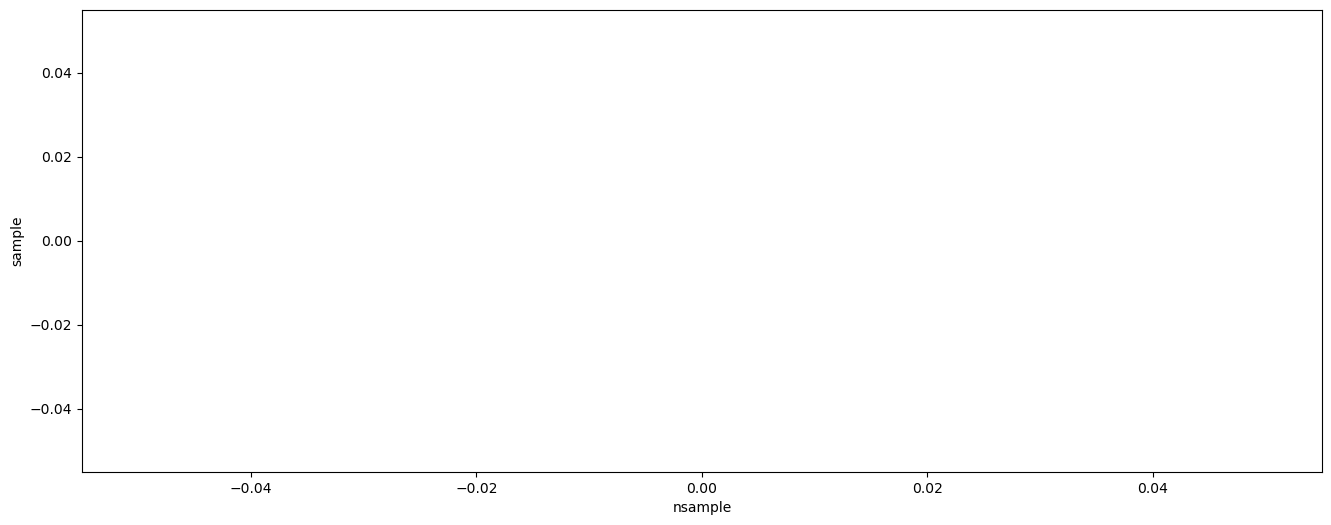

In [62]:
import seaborn as sns
sns.lineplot(data=dfres,x='nsample',y='sample',legend=None,ci=None,hue='traj')

In [63]:
def mod_vasicek(r0,K,theta,sigma,T=1,N=10,seed=777):
    np.random.seed(seed)
    dt = T/float(N)
    rates = [r0]
    for i in range(N):
        dr = K*(theta-rates[-1])*dt + sigma*np.random.normal()
        rates.append(rates[-1]+dr)
    return range(N+1), rates

In [64]:
import numpy as np

r0 = 0.1875
K = 0.2
theta = 0.04
sigma = 0.012
T = 10
seed = np.random.randint(100,900)
N = 1000
x , y = mod_vasicek(r0,K,theta,sigma,T,N,seed) 

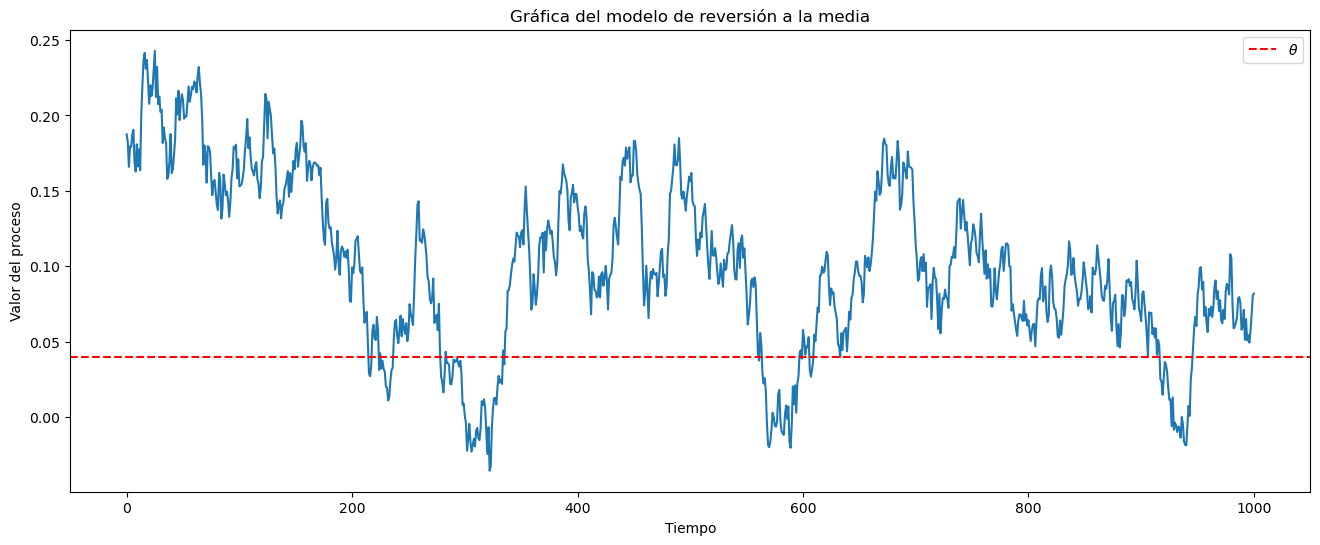

In [65]:
import matplotlib.pyplot as plt

plt.plot(x, y)
plt.title('Gráfica del modelo de reversión a la media')
plt.axhline(y=theta, color='red', linestyle='--', label=r'$\theta$')
plt.xlabel('Tiempo')
plt.ylabel('Valor del proceso')
plt.legend()
plt.show()

### Serie de tiempo autoregresiva (AR)

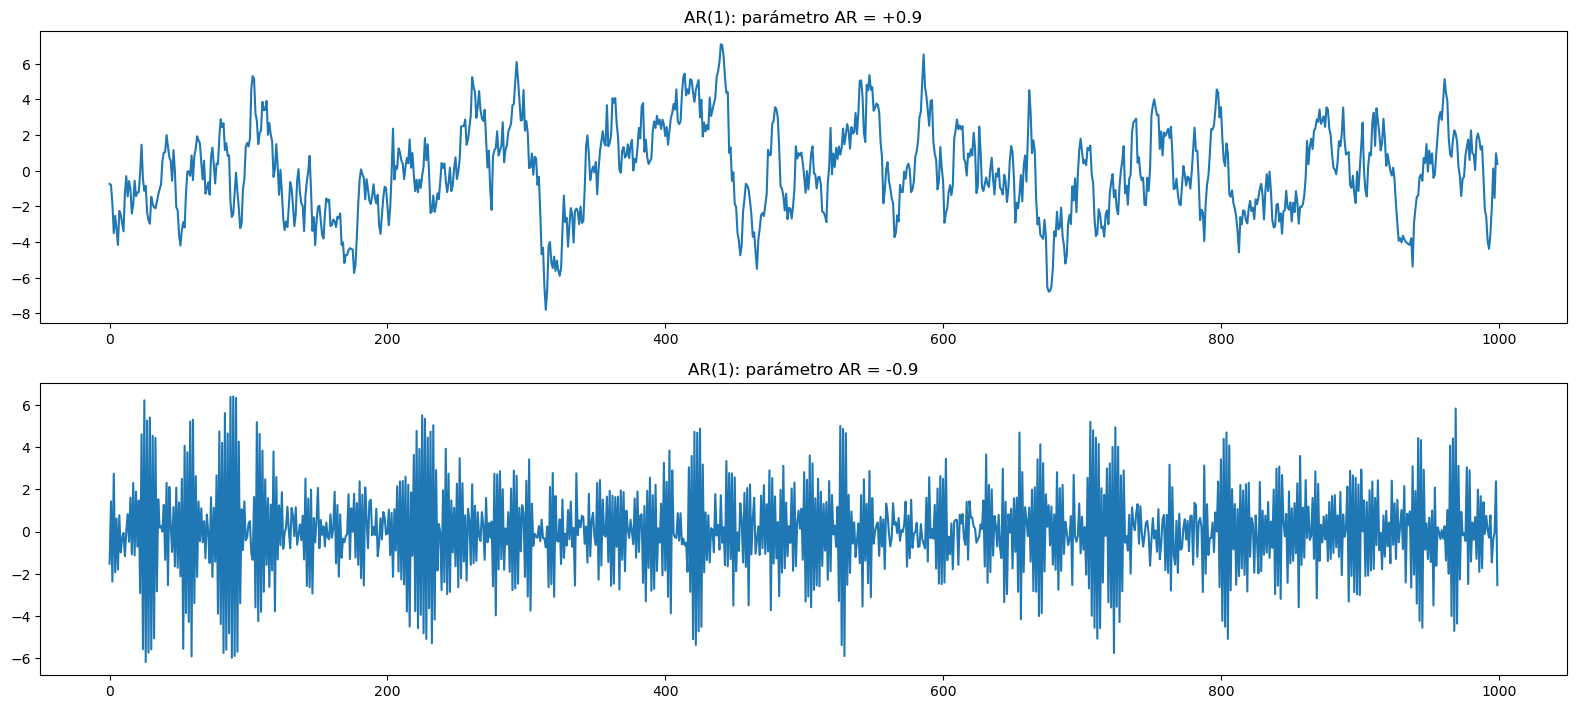

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from statsmodels.tsa.arima_process import ArmaProcess

rcParams['figure.figsize'] = (16, 14)

# Primer subplot
plt.subplot(4, 1, 1)

ar1 = np.array([1, -0.9])   # AR(1) con phi = 0.9
ma1 = np.array([1])

AR1 = ArmaProcess(ar1, ma1)
sim1 = AR1.generate_sample(nsample=1000)

plt.title('AR(1): parámetro AR = +0.9')
plt.plot(sim1)

# Segundo subplot
plt.subplot(4, 1, 2)

ar2 = np.array([1, 0.9])    # AR(1) con phi = -0.9
ma2 = np.array([1])

AR2 = ArmaProcess(ar2, ma2)
sim2 = AR2.generate_sample(nsample=1000)

plt.title('AR(1): parámetro AR = -0.9')
plt.plot(sim2)

plt.tight_layout()
plt.show()

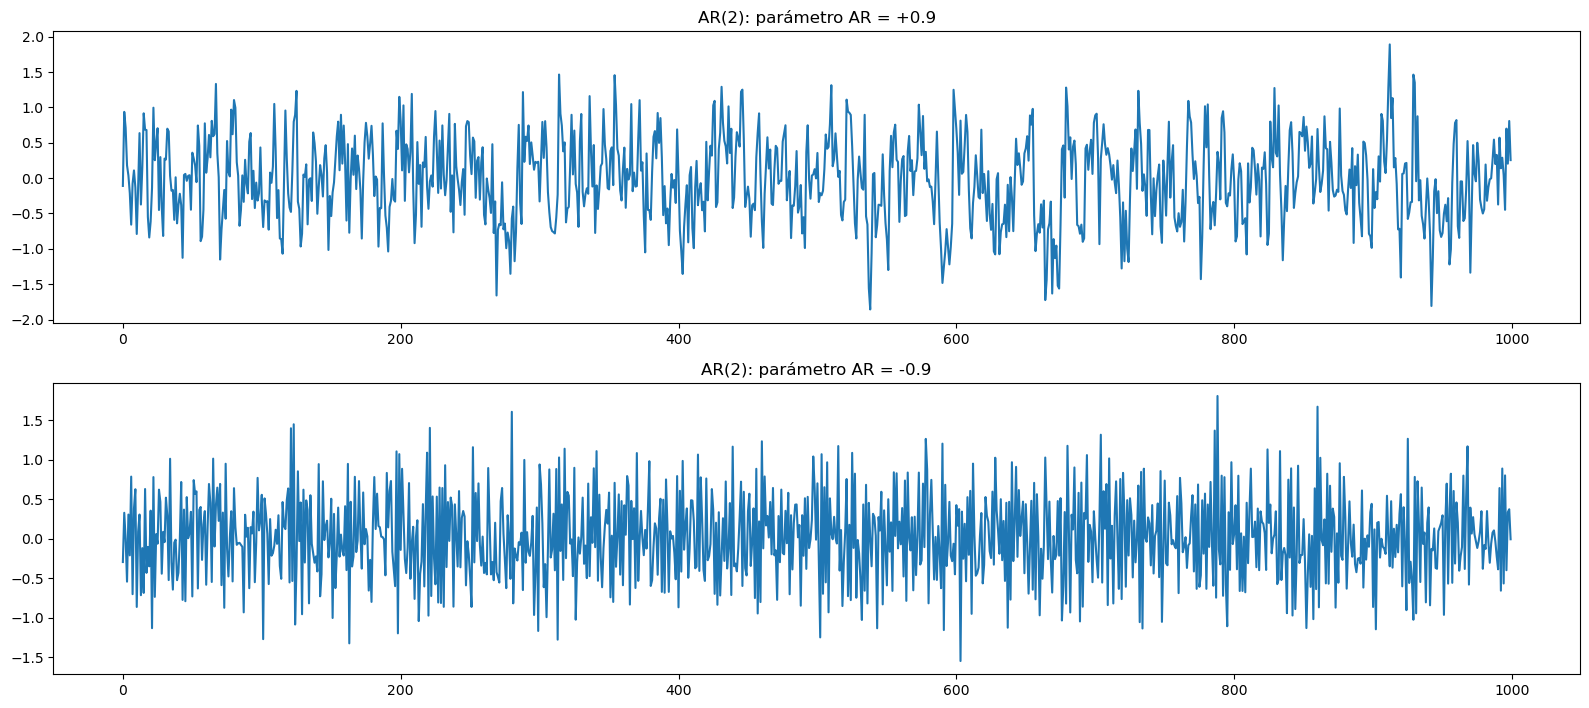

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from statsmodels.tsa.arima_process import ArmaProcess

rcParams['figure.figsize'] = (16, 14)

# Primer subplot
plt.subplot(4, 1, 3)

ar3 = np.array([2, -0.9])   # AR(1) con phi = 0.9
ma3 = np.array([1])

AR3 = ArmaProcess(ar3, ma3)
sim3 = AR3.generate_sample(nsample=1000)

plt.title('AR(2): parámetro AR = +0.9')
plt.plot(sim3)

# Segundo subplot
plt.subplot(4, 1, 4)

ar4 = np.array([2, 0.9])    # AR(1) con phi = -0.9
ma4 = np.array([1])

AR4 = ArmaProcess(ar4, ma4)
sim4 = AR4.generate_sample(nsample=1000)

plt.title('AR(2): parámetro AR = -0.9')
plt.plot(sim4)

plt.tight_layout()
plt.show()

### FORECASTING CON AR

In [68]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sim1, order=(1, 0, 0))  # AR(1)
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1471.166
Date:                Wed, 08 Jul 2026   AIC                           2948.331
Time:                        18:20:51   BIC                           2963.054
Sample:                             0   HQIC                          2953.927
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0285      0.349     -0.082      0.935      -0.713       0.656
ar.L1          0.9047      0.014     65.888      0.000       0.878       0.932
sigma2         1.1082      0.051     21.579      0.0

In [69]:
print('miu = {} ,phi = {}'.format(result.params[0],result.params[1]))
print(result.summary())


miu = -0.028548689316537722 ,phi = 0.9047257706490396
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1471.166
Date:                Wed, 08 Jul 2026   AIC                           2948.331
Time:                        18:20:51   BIC                           2963.054
Sample:                             0   HQIC                          2953.927
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0285      0.349     -0.082      0.935      -0.713       0.656
ar.L1          0.9047      0.014     65.888      0.000       0.878       0.93

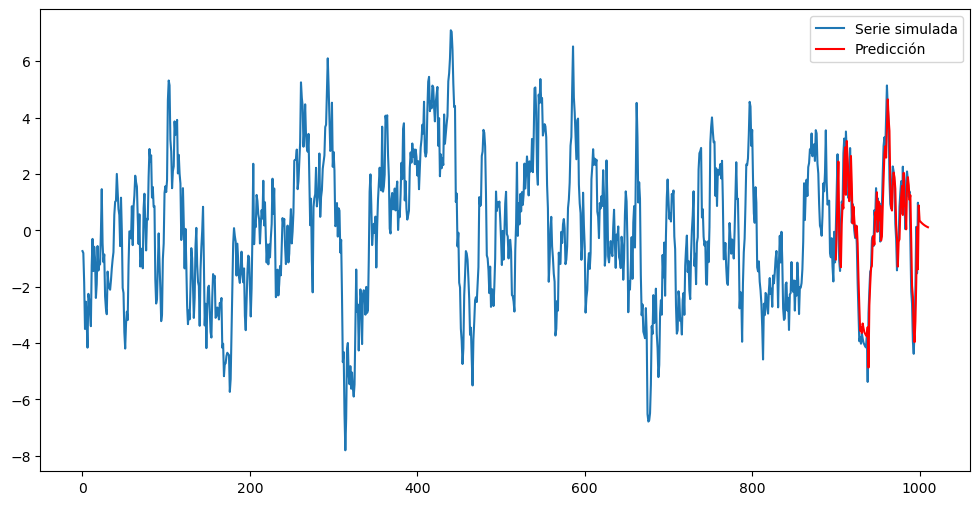

In [70]:
import matplotlib.pyplot as plt

# Predicciones
pred = result.predict(start=900, end=1010)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(sim1, label='Serie simulada')
plt.plot(range(900, 1011), pred, color='red', label='Predicción')
plt.legend()
plt.show()

In [72]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sim1, order=(1, 0, 0))  # AR(1)
result = model.fit()

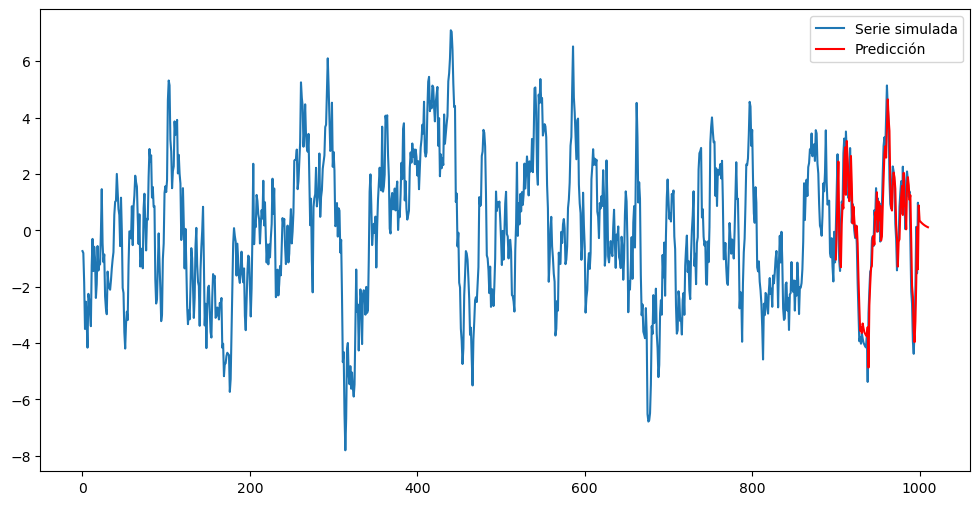

In [73]:
import matplotlib.pyplot as plt

# Predicciones
pred = result.predict(start=900, end=1010,dynamic=False)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(sim1, label='Serie simulada')
plt.plot(range(900, 1011), pred, color='red', label='Predicción')
plt.legend()
plt.show()



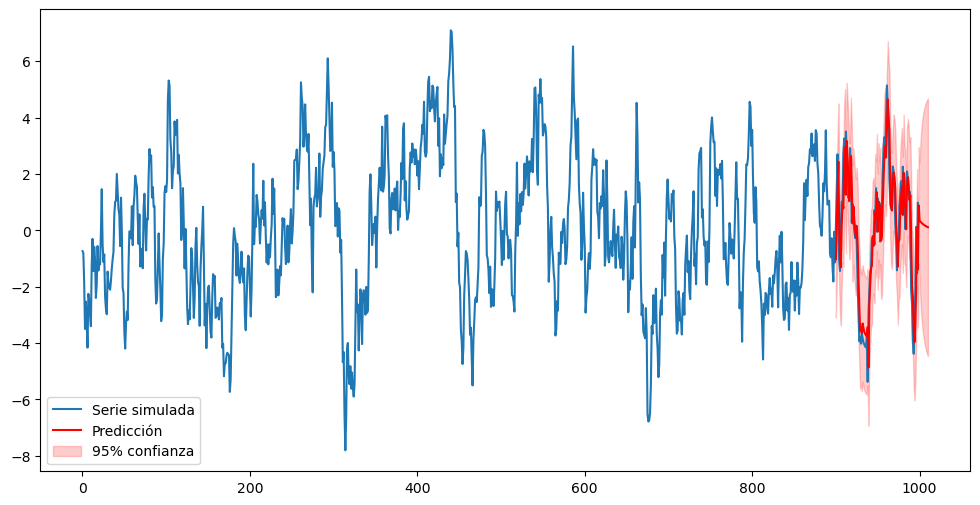

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Predicción
pred = result.get_prediction(start=900, end=1010, dynamic=False)

pred_mean = pred.predicted_mean
conf_int = pred.conf_int()

# Eje x correspondiente a las predicciones
x = np.arange(900, 1011)

plt.figure(figsize=(12,6))

# Serie completa
plt.plot(sim1, label='Serie simulada')

# Predicción
plt.plot(x, pred_mean, color='red', label='Predicción')

# Intervalo de confianza al 95%
plt.fill_between(
    x,
    conf_int[:, 0],
    conf_int[:, 1],
    color='red',
    alpha=0.2,
    label='95% confianza'
)

plt.legend()
plt.show()

In [78]:
import math
from sklearn.metrics import mean_squared_error
rmse = math.sqrt(mean_squared_error(sim1[900:1011], result.predict(start=900,end=999)))
print('RMSE ={}'.format(rmse))

RMSE =1.0545565297187103


In [82]:
#apple_price = ARMA(df_apple['Close'].diff().iloc[1:].values,order=(1,0))
#res = apple_price.fit(disp=0)
#res.plot_predict(start=1000,end=1100)
#plt.show()

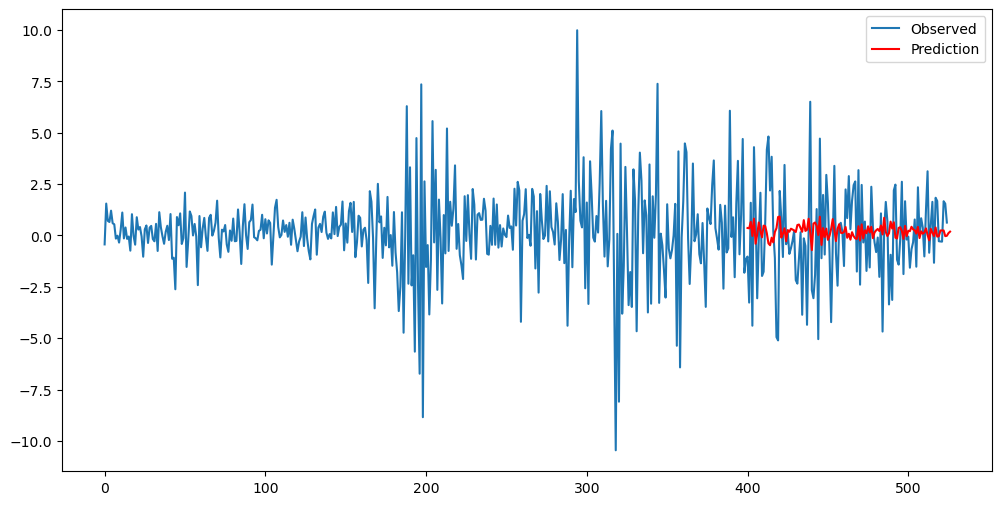

In [91]:
start = 400
end = 526

pred = res.predict(start=start, end=end)

plt.figure(figsize=(12,6))
plt.plot(y.values, label='Observed')
plt.plot(range(start, end+1), pred, color='red', label='Prediction')
plt.legend()
plt.show()

In [83]:
df_apple['Close'].diff().iloc[1:].values

array([-4.33704376e-01,  1.55348587e+00,  7.10586548e-01,  6.56684875e-01,
        1.20800781e+00,  5.95428467e-01,  5.46413422e-01, -1.51920319e-01,
       -9.79614258e-03, -3.45493317e-01,  2.81780243e-01,  1.11735153e+00,
       -1.42127991e-01,  3.89606476e-01, -1.66625977e-01, -4.90036011e-02,
       -7.37541199e-01,  1.03647995e+00, -1.47056580e-02, -4.45957184e-01,
        8.89461517e-01,  2.89138794e-01,  4.11655426e-01, -4.41093445e-02,
       -1.03158188e+00,  2.98946381e-01,  4.87598419e-01, -3.62632751e-01,
        3.79787445e-01,  4.68021393e-01, -1.73980713e-01, -2.81780243e-01,
        5.66017151e-01, -7.52246857e-01,  1.13449097e+00,  3.96953583e-01,
       -4.16603088e-02, -4.04293060e-01,  1.76418304e-01,  4.75353241e-01,
       -2.20516205e-01,  1.04382324e+00, -1.12959290e+00, -1.08057785e+00,
       -2.61692810e+00,  8.96804810e-01,  4.99866486e-01,  1.07568359e+00,
       -4.10755157e-01, -1.25442505e-01,  2.08822250e+00, -1.52988815e+00,
       -2.48420715e-01,  

In [98]:
rmse = math.sqrt(mean_squared_error(df_apple['High'].diff().iloc[120:127].values,result.predict(start=120,end=126)))
print('RMSE={}'.format(rmse))

RMSE=1.4141759765608808


### moving average series

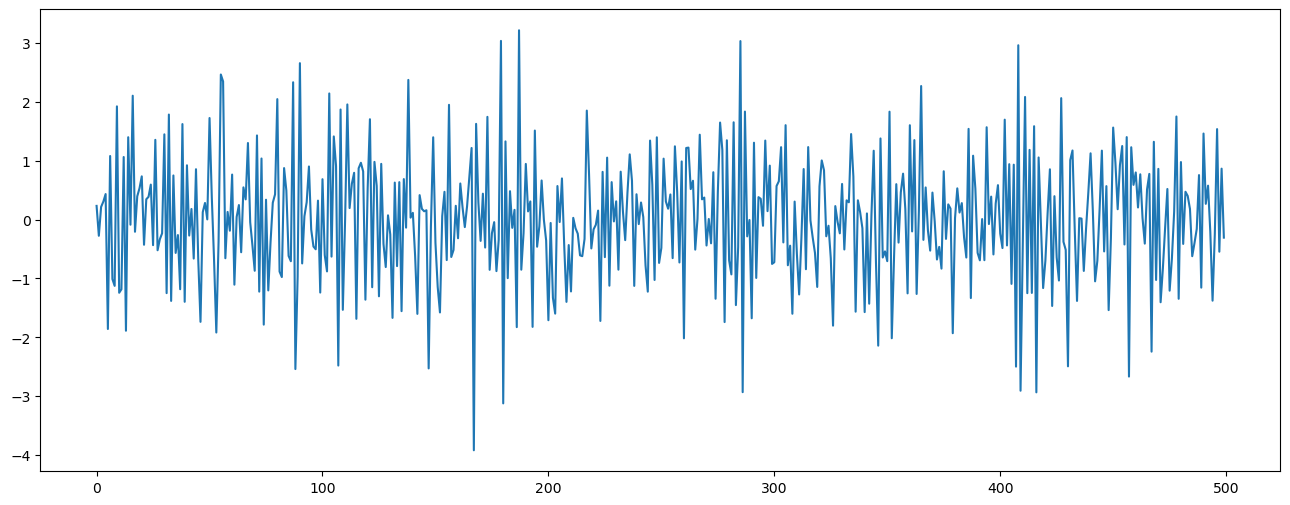

In [99]:
rcParams['figure.figsize'] = 16,6 
ar1 = np.array([1])
ma1 = np.array([1,-0.5])
MA1 = ArmaProcess(ar1,ma1)
sim1 = MA1.generate_sample(nsample=500)
plt.plot(sim1)

In [103]:
model = ARIMA(sim1, order=(0,0,1))
result = model.fit()

In [104]:
print('miu = {} ,phi = {}'.format(result.params[0],result.params[1]))
print(result.summary())


miu = 0.004214606231334908 ,phi = -0.40735000996955967
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -704.039
Date:                Wed, 08 Jul 2026   AIC                           1414.078
Time:                        18:57:24   BIC                           1426.722
Sample:                             0   HQIC                          1419.039
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0042      0.026      0.161      0.872      -0.047       0.056
ma.L1         -0.4074      0.040    -10.170      0.000      -0.486      -0.3

In [105]:
df_apple['Close'].diff().iloc[1:].values

array([-4.33704376e-01,  1.55348587e+00,  7.10586548e-01,  6.56684875e-01,
        1.20800781e+00,  5.95428467e-01,  5.46413422e-01, -1.51920319e-01,
       -9.79614258e-03, -3.45493317e-01,  2.81780243e-01,  1.11735153e+00,
       -1.42127991e-01,  3.89606476e-01, -1.66625977e-01, -4.90036011e-02,
       -7.37541199e-01,  1.03647995e+00, -1.47056580e-02, -4.45957184e-01,
        8.89461517e-01,  2.89138794e-01,  4.11655426e-01, -4.41093445e-02,
       -1.03158188e+00,  2.98946381e-01,  4.87598419e-01, -3.62632751e-01,
        3.79787445e-01,  4.68021393e-01, -1.73980713e-01, -2.81780243e-01,
        5.66017151e-01, -7.52246857e-01,  1.13449097e+00,  3.96953583e-01,
       -4.16603088e-02, -4.04293060e-01,  1.76418304e-01,  4.75353241e-01,
       -2.20516205e-01,  1.04382324e+00, -1.12959290e+00, -1.08057785e+00,
       -2.61692810e+00,  8.96804810e-01,  4.99866486e-01,  1.07568359e+00,
       -4.10755157e-01, -1.25442505e-01,  2.08822250e+00, -1.52988815e+00,
       -2.48420715e-01,  

In [109]:
model = ARIMA(df_apple['Close'].diff().iloc[1:].values, order = (0,0,3))
result = model.fit()

In [110]:
print(result.summary())
print('miu={}, phi={}'.format(result.params[0],result.params[1]))

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  525
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1135.468
Date:                Wed, 08 Jul 2026   AIC                           2280.936
Time:                        19:01:12   BIC                           2302.253
Sample:                             0   HQIC                          2289.284
                                - 525                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1787      0.082      2.175      0.030       0.018       0.340
ma.L1         -0.1365      0.034     -4.060      0.000      -0.202      -0.071
ma.L2          0.0399      0.027      1.485      0.1

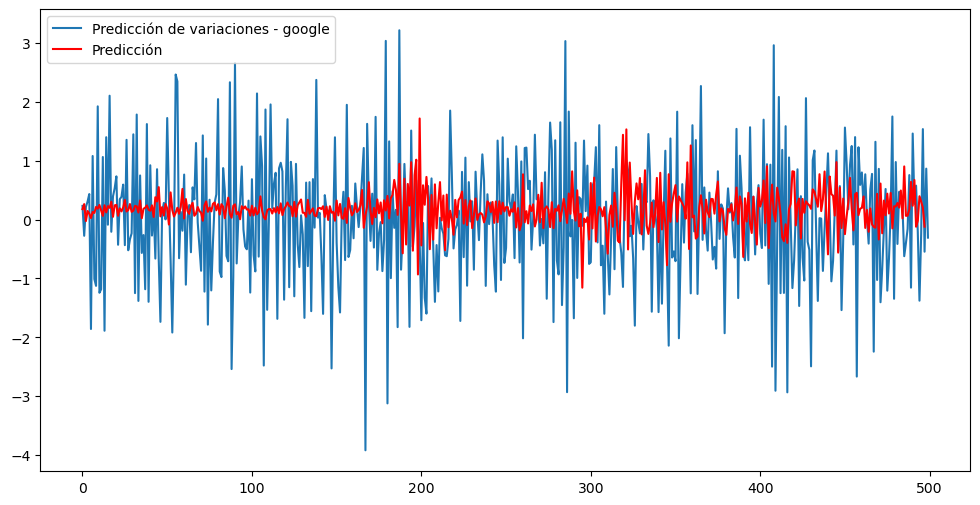

In [121]:
import matplotlib.pyplot as plt

# Predicciones
pred = result.predict(start=0, end=497)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(sim1, label='Predicción de variaciones - google')
plt.plot(range(0, 498), pred, color='red', label='Predicción')
plt.legend()
plt.show()

In [124]:
rmse = math.sqrt(mean_squared_error(df_apple['High'].diff().iloc[400:500].values,result.predict(start=400,end=499)))
print('RMSE ={}'.format(rmse))

RMSE =2.1743542553943813


In [125]:
model = ARIMA(df_apple['Close'].values,order=(0,0,3))
result = model.fit()

In [134]:
import pandas as pd
import numpy as np

# For reproducibility
np.random.seed(42)

# Generate 500 consecutive dates
dates = pd.date_range(start='2024-01-01', periods=500, freq='D')

# Generate 500 temperature samples (mean = 25°C, std = 5°C)
temperatures = np.random.normal(loc=25, scale=5, size=500)

# Create the DataFrame
df_sp = pd.DataFrame({
    'Date': dates,
    'Temp': temperatures
})

# Round temperatures to 2 decimal places
df_sp['Temp'] = df_sp['Temp'].round(2)

print(df_sp.head())

        Date   Temp
0 2024-01-01  27.48
1 2024-01-02  24.31
2 2024-01-03  28.24
3 2024-01-04  32.62
4 2024-01-05  23.83


<Axes: >

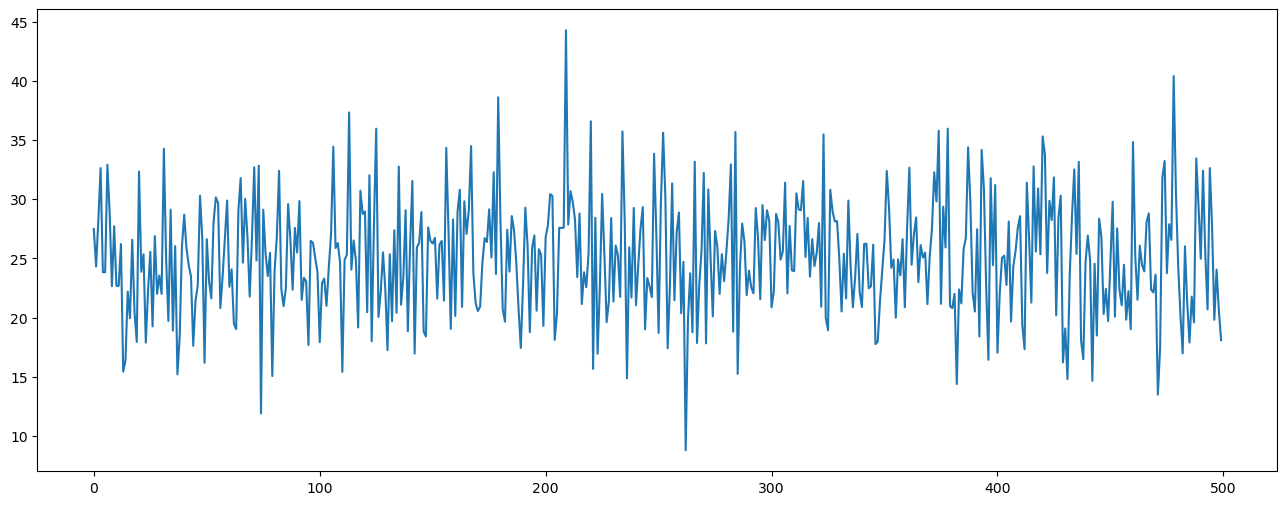

In [138]:
df_sp['Temp'].plot()

In [135]:
model = ARIMA(df_sp['Temp'].diff().iloc[1:].values, order = (0,0,3))
result = model.fit()

In [136]:
print(result.summary())
print('miu = {}, phi={}'.format(result.params[0],result.params[1]))

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  499
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1504.701
Date:                Wed, 08 Jul 2026   AIC                           3019.401
Time:                        21:42:36   BIC                           3040.464
Sample:                             0   HQIC                          3027.667
                                - 499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.002      0.380      0.704      -0.003       0.005
ma.L1         -1.0022      0.692     -1.449      0.147      -2.358       0.354
ma.L2         -0.0062      0.066     -0.094      0.9

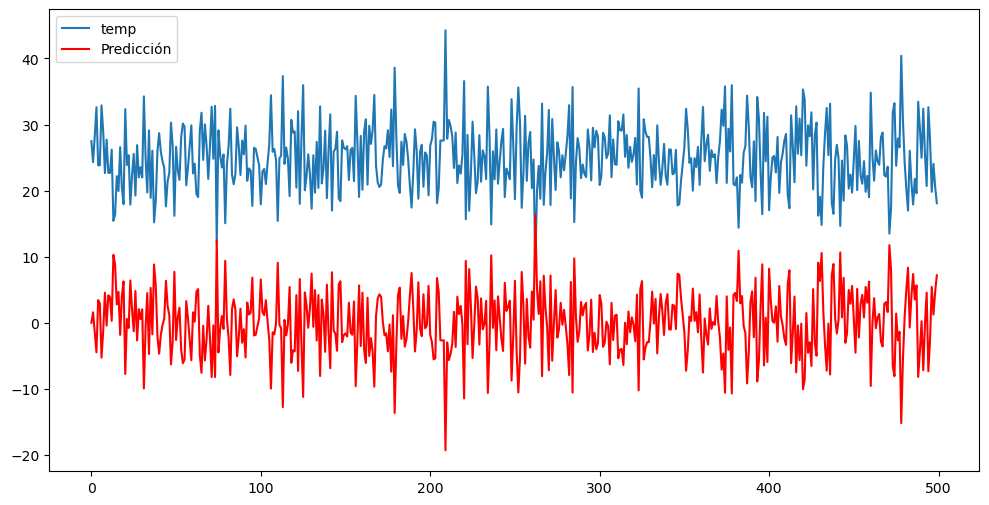

In [141]:
import matplotlib.pyplot as plt

# Predicciones
pred = result.predict(start=0, end=499)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(df_sp['Temp'], label='temp')
plt.plot(range(0, 500), pred, color='red', label='Predicción')
plt.legend()
plt.show()